In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('bank-additional-full.csv', delimiter=';', decimal='.')
print(df.columns.tolist())
data = pd.get_dummies(df, columns=["job","marital","education","default","housing","loan","contact","month","day_of_week",'poutcome',])

data = data.dropna(axis=1, how='all')  
data.fillna(data.mean(numeric_only=True), inplace=True)
X = data.drop(['y'], axis=1).values
le = LabelEncoder()
y = le.fit_transform(data['y'].values)
 

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

print(pd.Series(y).value_counts())



# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

scaler = StandardScaler()
X = scaler.fit_transform(X)
# X_test = scaler.transform(X_test)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Признаков: 63, Объектов: 41188
0    36548
1     4640
Name: count, dtype: int64


K-means

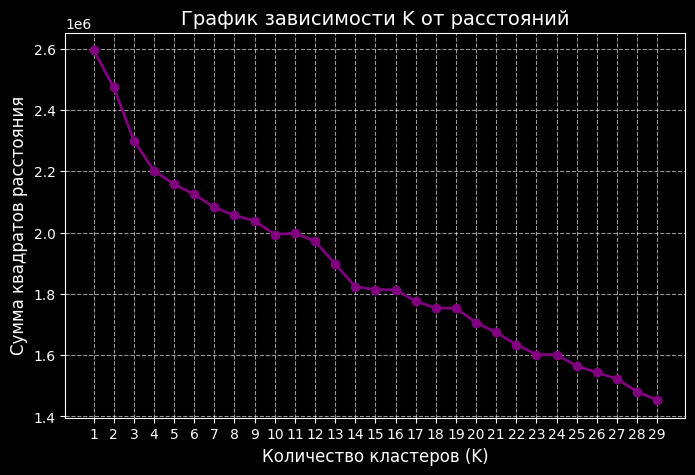

In [7]:
mean_distances = []
k_range = range(1, 30)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    mean_distances.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, mean_distances, marker='o', color='purple', linestyle='-', linewidth=2)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Сумма квадратов расстояния', fontsize=12)
plt.title('График зависимости K от расстояний', fontsize=14)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
kmeans.fit(X)
kmeans_labels = kmeans.labels_
print(np.unique(kmeans_labels))

score = kmeans.score(X)
print(f"Score: {score:.2f}")
for i in range(4):
    print(f"Кластер {i}: {np.sum(kmeans_labels==i)} объектов")


[0 1 2 3]
Score: -2201138.98
Кластер 0: 13532 объектов
Кластер 1: 1517 объектов
Кластер 2: 13450 объектов
Кластер 3: 12689 объектов


In [31]:
data.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'mon

In [42]:
cluster_data = data[
    [
        'age',
        'duration',
        'marital_divorced',
        'marital_married',
        'marital_single',
        'marital_unknown',
        'loan_yes',
        'housing_yes'
    ]
].copy()

cluster_data['cluster'] = kmeans_labels

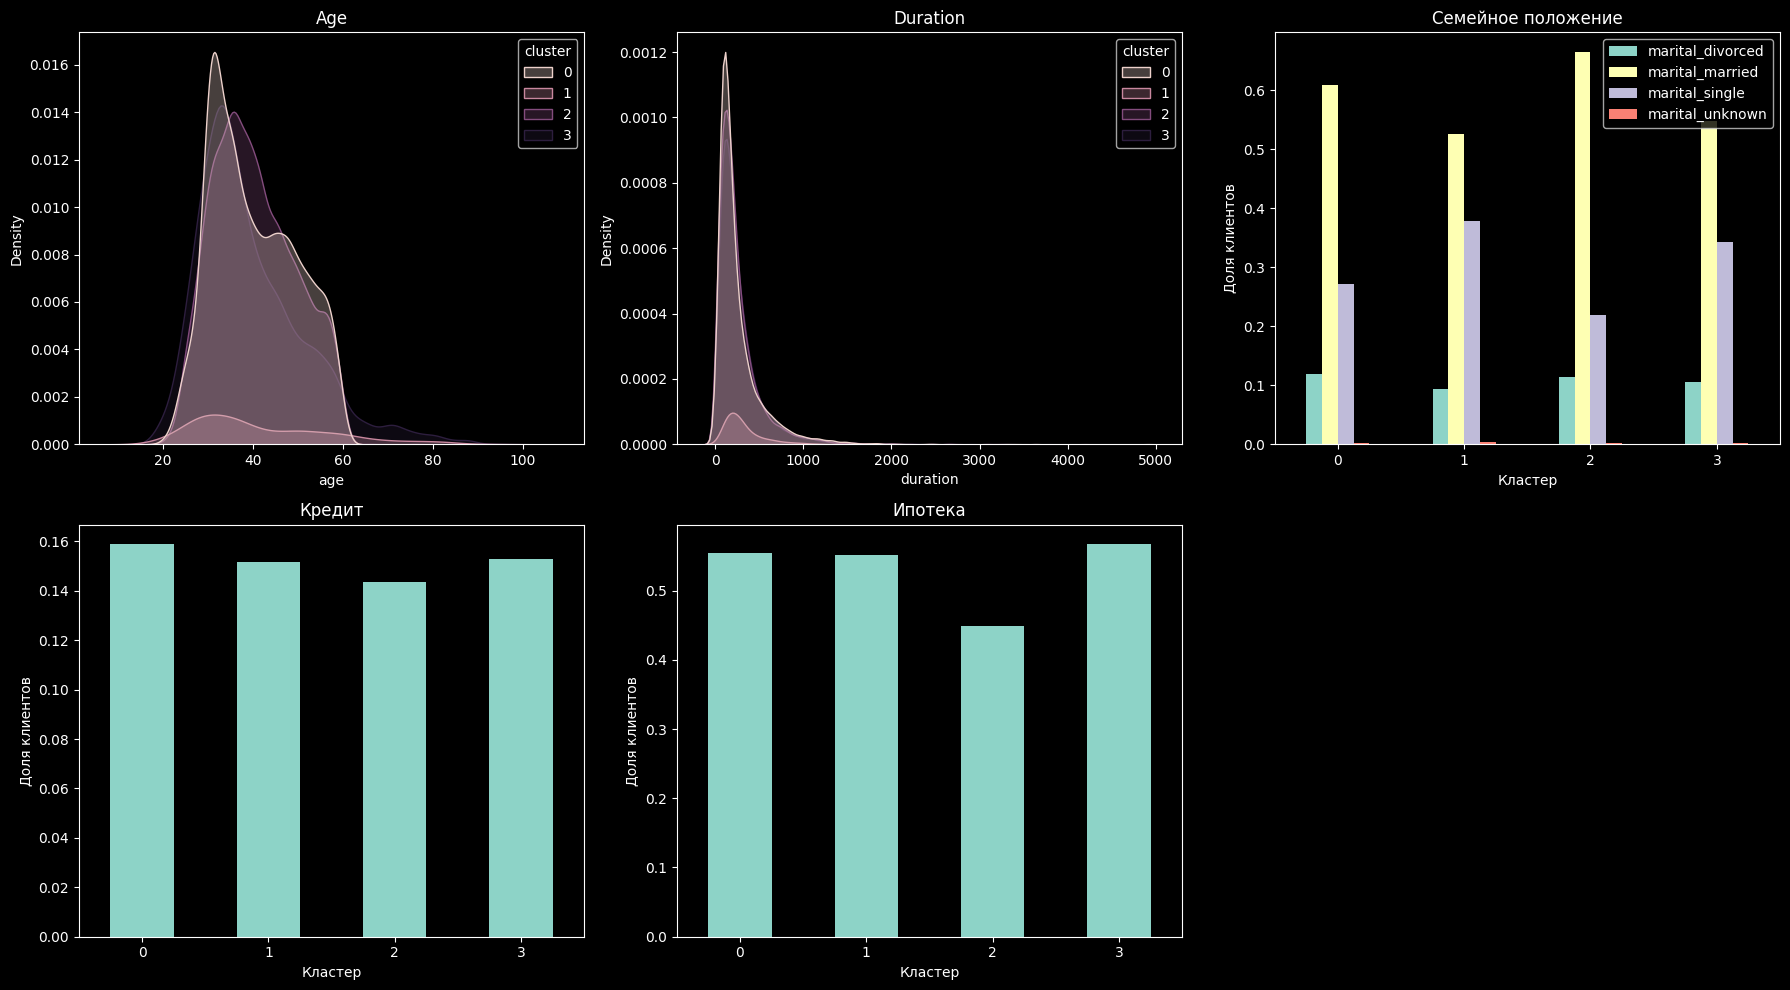

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))


sns.kdeplot(
    data=cluster_data,
    x='age',
    hue='cluster',
    fill=True,
    alpha=0.3,
    ax=axes[0,0]
)

axes[0,0].set_title('Age')


sns.kdeplot(
    data=cluster_data,
    x='duration',
    hue='cluster',
    fill=True,
    alpha=0.3,
    ax=axes[0,1]
)

axes[0,1].set_title('Duration')


marital_cluster = cluster_data.groupby('cluster')[
    [
        'marital_divorced',
        'marital_married',
        'marital_single',
        'marital_unknown'
    ]
].mean()


marital_cluster.plot(
    kind='bar',
    ax=axes[0,2]
)

axes[0,2].set_title('Семейное положение')
axes[0,2].set_xlabel('Кластер')
axes[0,2].set_ylabel('Доля клиентов')

axes[0,2].tick_params(axis='x', rotation=0)


loan_cluster = cluster_data.groupby('cluster')[
    'loan_yes'
].mean()


loan_cluster.plot(
    kind='bar',
    ax=axes[1,0],
    legend=False
)

axes[1,0].set_title('Кредит')
axes[1,0].set_xlabel('Кластер')
axes[1,0].set_ylabel('Доля клиентов')

axes[1,0].tick_params(axis='x', rotation=0)



housing_cluster = cluster_data.groupby('cluster')[
    'housing_yes'
].mean()


housing_cluster.plot(
    kind='bar',
    ax=axes[1,1],
    legend=False
)

axes[1,1].set_title('Ипотека')
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Доля клиентов')

axes[1,1].tick_params(axis='x', rotation=0)


axes[1,2].axis('off')


plt.tight_layout()

plt.show()

Agglomerative Clustering

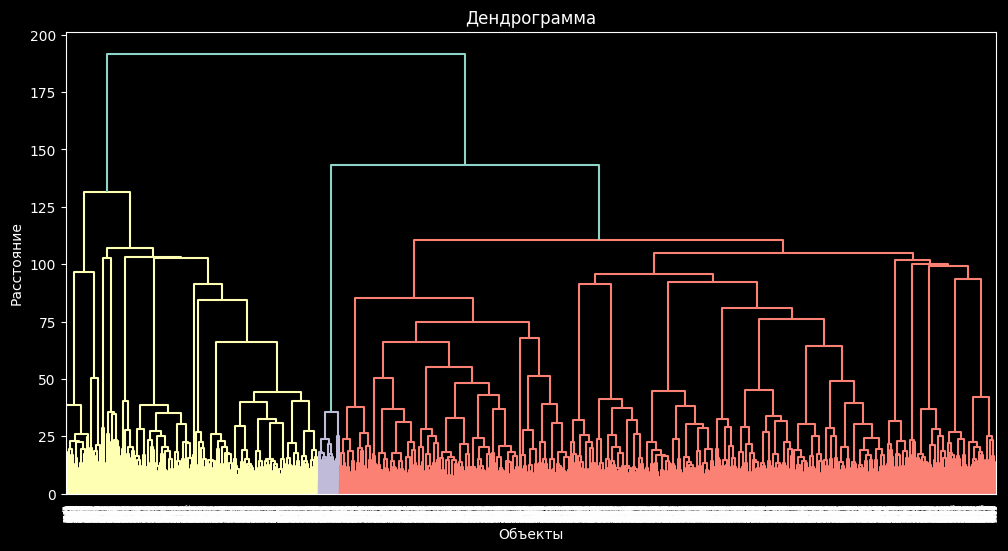

Кластер 0: 1359 объектов
Кластер 1: 3528 объектов
Кластер 2: 113 объектов


In [48]:
X_sample = resample(X, n_samples=5000, random_state=42, replace=False)
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Дендрограмма')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = model.fit_predict(X_sample)

for i in range(3):
    print(f"Кластер {i}: {np.sum(agg_labels==i)} объектов")

In [52]:
cluster_data = data.iloc[:5000][
    [
        'age',
        'duration',
        'marital_divorced',
        'marital_married',
        'marital_single',
        'marital_unknown',
        'loan_yes',
        'housing_yes'
    ]
].copy()

cluster_data['cluster'] = agg_labels

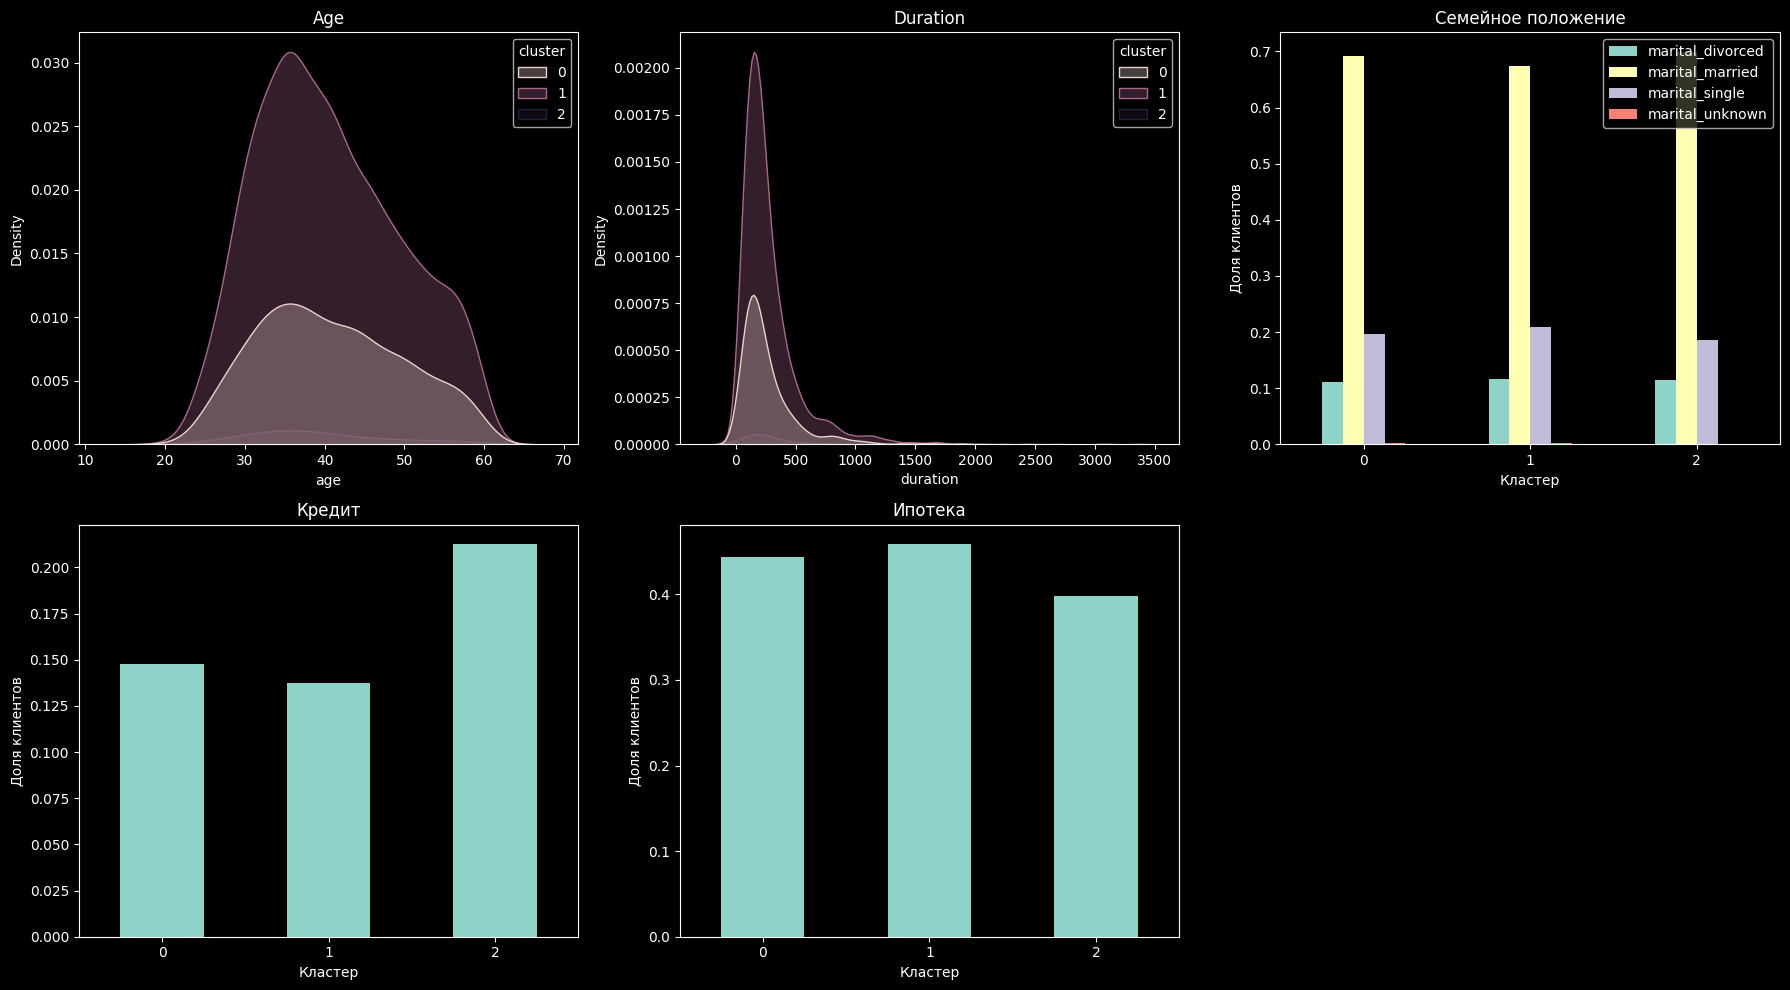

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))


sns.kdeplot(
    data=cluster_data,
    x='age',
    hue='cluster',
    fill=True,
    alpha=0.3,
    ax=axes[0,0]
)

axes[0,0].set_title('Age')


sns.kdeplot(
    data=cluster_data,
    x='duration',
    hue='cluster',
    fill=True,
    alpha=0.3,
    ax=axes[0,1]
)

axes[0,1].set_title('Duration')


marital_cluster = cluster_data.groupby('cluster')[
    [
        'marital_divorced',
        'marital_married',
        'marital_single',
        'marital_unknown'
    ]
].mean()


marital_cluster.plot(
    kind='bar',
    ax=axes[0,2]
)

axes[0,2].set_title('Семейное положение')
axes[0,2].set_xlabel('Кластер')
axes[0,2].set_ylabel('Доля клиентов')

axes[0,2].tick_params(axis='x', rotation=0)


loan_cluster = cluster_data.groupby('cluster')[
    'loan_yes'
].mean()


loan_cluster.plot(
    kind='bar',
    ax=axes[1,0],
    legend=False
)

axes[1,0].set_title('Кредит')
axes[1,0].set_xlabel('Кластер')
axes[1,0].set_ylabel('Доля клиентов')

axes[1,0].tick_params(axis='x', rotation=0)



housing_cluster = cluster_data.groupby('cluster')[
    'housing_yes'
].mean()


housing_cluster.plot(
    kind='bar',
    ax=axes[1,1],
    legend=False
)

axes[1,1].set_title('Ипотека')
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Доля клиентов')

axes[1,1].tick_params(axis='x', rotation=0)


axes[1,2].axis('off')


plt.tight_layout()

plt.show()

DBSCAN

In [54]:
clustering = DBSCAN(eps=9, min_samples=10).fit(X)
dbscan_labels = clustering.labels_

n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 7
Estimated number of noise points: 123


In [55]:
for cluster in np.unique(dbscan_labels):
    if cluster == -1:
        continue

    print(f"\nCluster {cluster}")
    print(X[dbscan_labels == cluster].mean(axis=0))


Cluster 0
[-0.00891795 -0.00147931  0.00215839  0.01578395 -0.01374828  0.02329901
  0.01386692 -0.00423061  0.02483652  0.02927347  0.00474945  0.00929914
  0.00427391  0.00056288  0.00232105 -0.00736905 -0.00069596  0.00615821
 -0.00710453  0.00432874 -0.00130184 -0.08987076  0.00170852  0.00545926
 -0.00281462 -0.04411455 -0.00248955  0.0020996   0.00482446  0.00534722
 -0.0209096   0.00111209 -0.00070592 -0.01645863 -0.00176487  0.00194432
 -0.00853476  0.02402287 -0.1569334   0.02418729  0.05359611 -0.1569334
  0.01014129 -0.00336148  0.00336148  0.00662215  0.00799513 -0.06662113
  0.01084702  0.00193389 -0.11590677  0.0113233   0.00972626  0.00037237
  0.00116054  0.00217214 -0.00248985  0.00101969 -0.00291104  0.00225502
 -0.00483296  0.0121404  -0.01503216]

Cluster 1
[ 5.22719079e-01 -8.23147569e-02  5.27845745e-02 -3.74912610e-02
 -1.11372863e-01  2.83516262e-01  3.38220756e-01  2.76432322e-01
  2.78164975e-01  1.96409143e-01 -5.82022825e-01 -5.38316990e-01
 -1.91430209e-01

In [56]:
for cluster in np.unique(dbscan_labels):
    if cluster == -1:
        continue

    print(f"\nCluster {cluster}")

    mean = X[dbscan_labels == cluster].mean(axis=0)

    for i, value in enumerate(mean):
        print(f"Feature {i:2d}: {value:.3f}")


Cluster 0
Feature  0: -0.009
Feature  1: -0.001
Feature  2: 0.002
Feature  3: 0.016
Feature  4: -0.014
Feature  5: 0.023
Feature  6: 0.014
Feature  7: -0.004
Feature  8: 0.025
Feature  9: 0.029
Feature 10: 0.005
Feature 11: 0.009
Feature 12: 0.004
Feature 13: 0.001
Feature 14: 0.002
Feature 15: -0.007
Feature 16: -0.001
Feature 17: 0.006
Feature 18: -0.007
Feature 19: 0.004
Feature 20: -0.001
Feature 21: -0.090
Feature 22: 0.002
Feature 23: 0.005
Feature 24: -0.003
Feature 25: -0.044
Feature 26: -0.002
Feature 27: 0.002
Feature 28: 0.005
Feature 29: 0.005
Feature 30: -0.021
Feature 31: 0.001
Feature 32: -0.001
Feature 33: -0.016
Feature 34: -0.002
Feature 35: 0.002
Feature 36: -0.009
Feature 37: 0.024
Feature 38: -0.157
Feature 39: 0.024
Feature 40: 0.054
Feature 41: -0.157
Feature 42: 0.010
Feature 43: -0.003
Feature 44: 0.003
Feature 45: 0.007
Feature 46: 0.008
Feature 47: -0.067
Feature 48: 0.011
Feature 49: 0.002
Feature 50: -0.116
Feature 51: 0.011
Feature 52: 0.010
Feature 53: 0

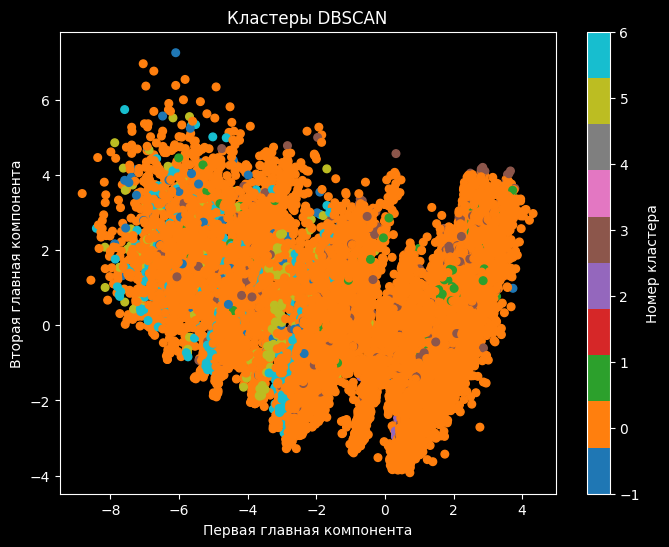

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap='tab10',
    s=30
)

plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Кластеры DBSCAN")
plt.colorbar(label="Номер кластера")
plt.show()

In [58]:
unique, counts = np.unique(dbscan_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

Cluster -1: 123
Cluster 0: 39071
Cluster 1: 297
Cluster 2: 57
Cluster 3: 928
Cluster 4: 12
Cluster 5: 173
Cluster 6: 527


In [65]:
selected_clusters = [0, 3, 6]

mask = np.isin(dbscan_labels, selected_clusters)

X_selected = X[mask]
labels_selected = dbscan_labels[mask]

In [67]:
cluster_data = data[
    [
        'age',
        'duration',
        'marital_divorced',
        'marital_married',
        'marital_single',
        'marital_unknown',
        'loan_yes',
        'housing_yes'
    ]
].copy()

cluster_data = cluster_data[mask]

cluster_data['cluster'] = labels_selected

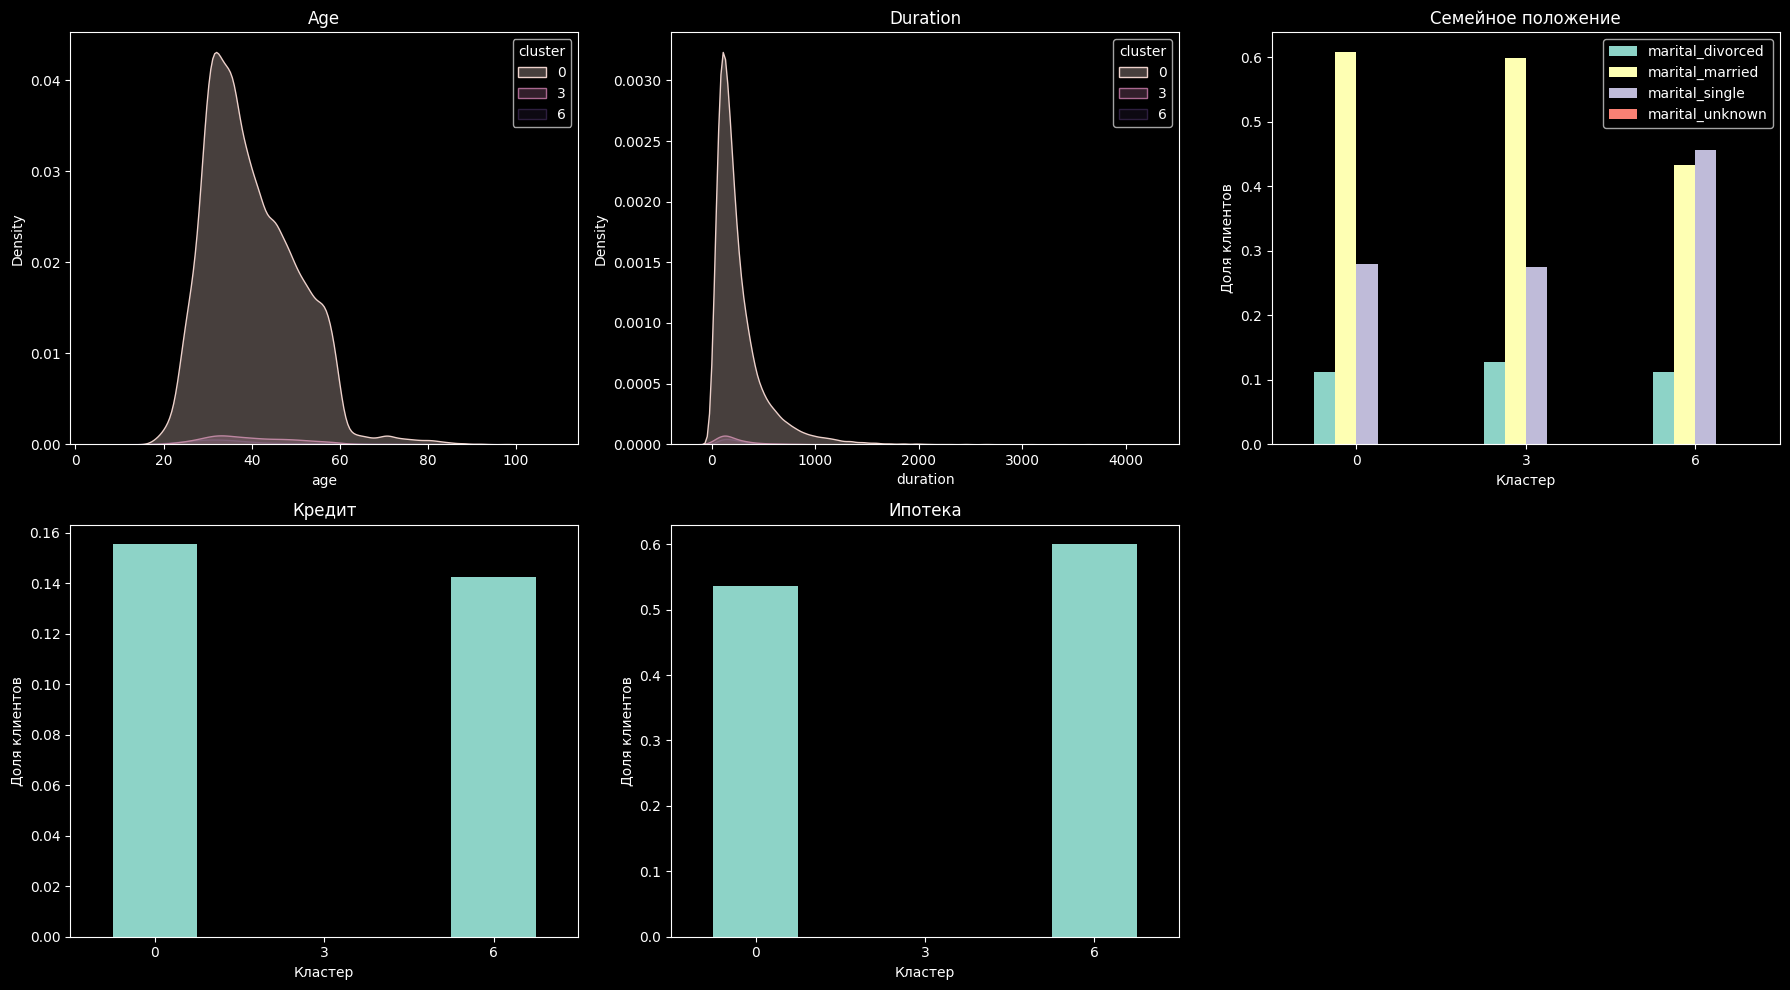

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))


sns.kdeplot(
    data=cluster_data,
    x='age',
    hue='cluster',
    fill=True,
    alpha=0.3,
    ax=axes[0,0]
)

axes[0,0].set_title('Age')


sns.kdeplot(
    data=cluster_data,
    x='duration',
    hue='cluster',
    fill=True,
    alpha=0.3,
    ax=axes[0,1]
)

axes[0,1].set_title('Duration')


marital_cluster = cluster_data.groupby('cluster')[
    [
        'marital_divorced',
        'marital_married',
        'marital_single',
        'marital_unknown'
    ]
].mean()


marital_cluster.plot(
    kind='bar',
    ax=axes[0,2]
)

axes[0,2].set_title('Семейное положение')
axes[0,2].set_xlabel('Кластер')
axes[0,2].set_ylabel('Доля клиентов')

axes[0,2].tick_params(axis='x', rotation=0)


loan_cluster = cluster_data.groupby('cluster')[
    'loan_yes'
].mean()


loan_cluster.plot(
    kind='bar',
    ax=axes[1,0],
    legend=False
)

axes[1,0].set_title('Кредит')
axes[1,0].set_xlabel('Кластер')
axes[1,0].set_ylabel('Доля клиентов')

axes[1,0].tick_params(axis='x', rotation=0)



housing_cluster = cluster_data.groupby('cluster')[
    'housing_yes'
].mean()


housing_cluster.plot(
    kind='bar',
    ax=axes[1,1],
    legend=False
)

axes[1,1].set_title('Ипотека')
axes[1,1].set_xlabel('Кластер')
axes[1,1].set_ylabel('Доля клиентов')

axes[1,1].tick_params(axis='x', rotation=0)


axes[1,2].axis('off')


plt.tight_layout()

plt.show()